In [40]:
import numpy as np 
import pandas as pd 
import matplotlib as mpl 
import matplotlib.pyplot as plt
import seaborn as sns

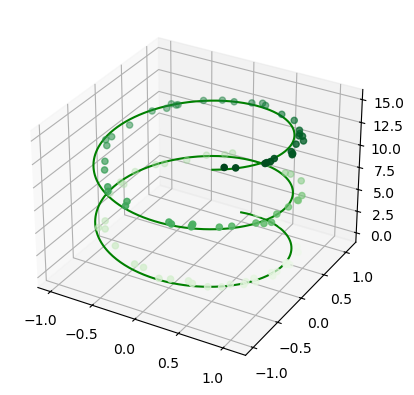

In [41]:
# Трехмерные точки и линии
fig = plt.figure()
ax = plt.axes(projection='3d')
z1 = np.linspace(0, 15, 1000) 
y1 = np.cos(z1)
x1 = np.sin(z1)

ax.plot3D (x1, y1, z1, 'green')

z2 = 15 * np.random.random(100)
y2 = np.cos(z2) + 0.1 * np.random.random(100)
x2 = np.sin(z2) + 0.1 * np.random.random(100)

ax.scatter3D (x2, y2, z2, c=z2, cmap='Greens')

plt.show()

In [42]:
def f(x,y):
    return np.sin(np.sqrt(x ** 2 + y ** 2))

x = np.linspace(-6, 6, 30) 
y = np.linspace(-6, 6, 30) 
X, Y = np.meshgrid(x, y) 
Z = f(X, Y)
ax.contour3D(X, Y, Z, 40, cmap='binary')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.view_init(60, 45)

plt.show()

In [43]:
# каркасный
ax.plot_wireframe(X, Y, Z)

In [44]:
# поверхностный
ax.plot_surface (X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_title ('Example')

Text(0.5, 0.92, 'Example')

In [45]:
r = np.linspace(0, 6, 20)
theta = np.linspace (-0.9 * np.pi, 0.8* np.pi, 40)

R, Theta = np.meshgrid(r, theta)

X = r * np.sin(Theta)
Y = r * np.cos(Theta)
Z = f(X, Y)
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

plt.show()

In [46]:
theta = 2 * np.pi + np.random.random(1000) 
r = 6 * np.random.random(1000)

x = r * np.sin(theta) 
y = r * np.cos (theta)
z = f(x,y)

ax.scatter(x, y, z, c=z, cmap='viridis')
ax.plot_trisurf(x, y, z, cmap='viridis')

plt.show()

          x         y
0 -0.710024 -0.960463
1 -1.828413 -3.932593
2 -1.826043 -1.697374
3  2.110263 -0.454500
4  2.778277  0.144427


C:\Users\Polina\AppData\Local\Temp\ipykernel_9044\2296557181.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=data, shade=True)


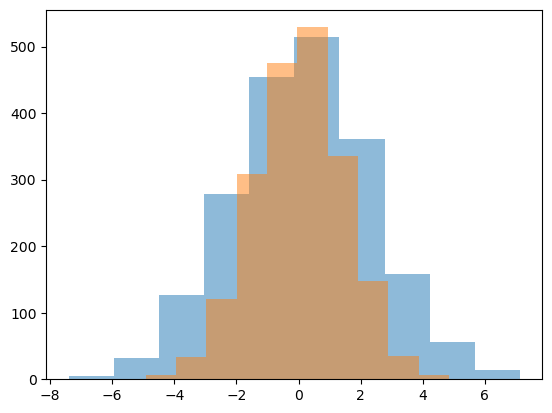

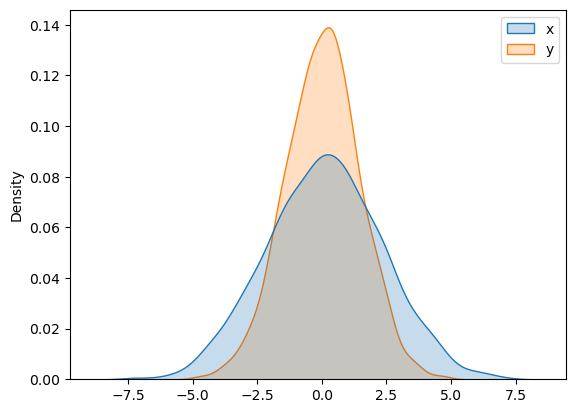

In [47]:
# Seaborn
# - DataFrame (Matplotlib c Pandas)
# - более высокоуровневый
data = np.random.multivariate_normal([0,0], [[5,2], [2,2]], size = 2000) 
data = pd.DataFrame(data, columns=['x', 'y'])

print(data.head())

fig = plt.figure()
plt.hist (data['x'], alpha=0.5) 
plt.hist (data['y'], alpha=0.5)

fig = plt.figure()
sns.kdeplot(data=data, shade=True)

plt.show()

In [48]:
iris = sns.load_dataset('iris')
print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


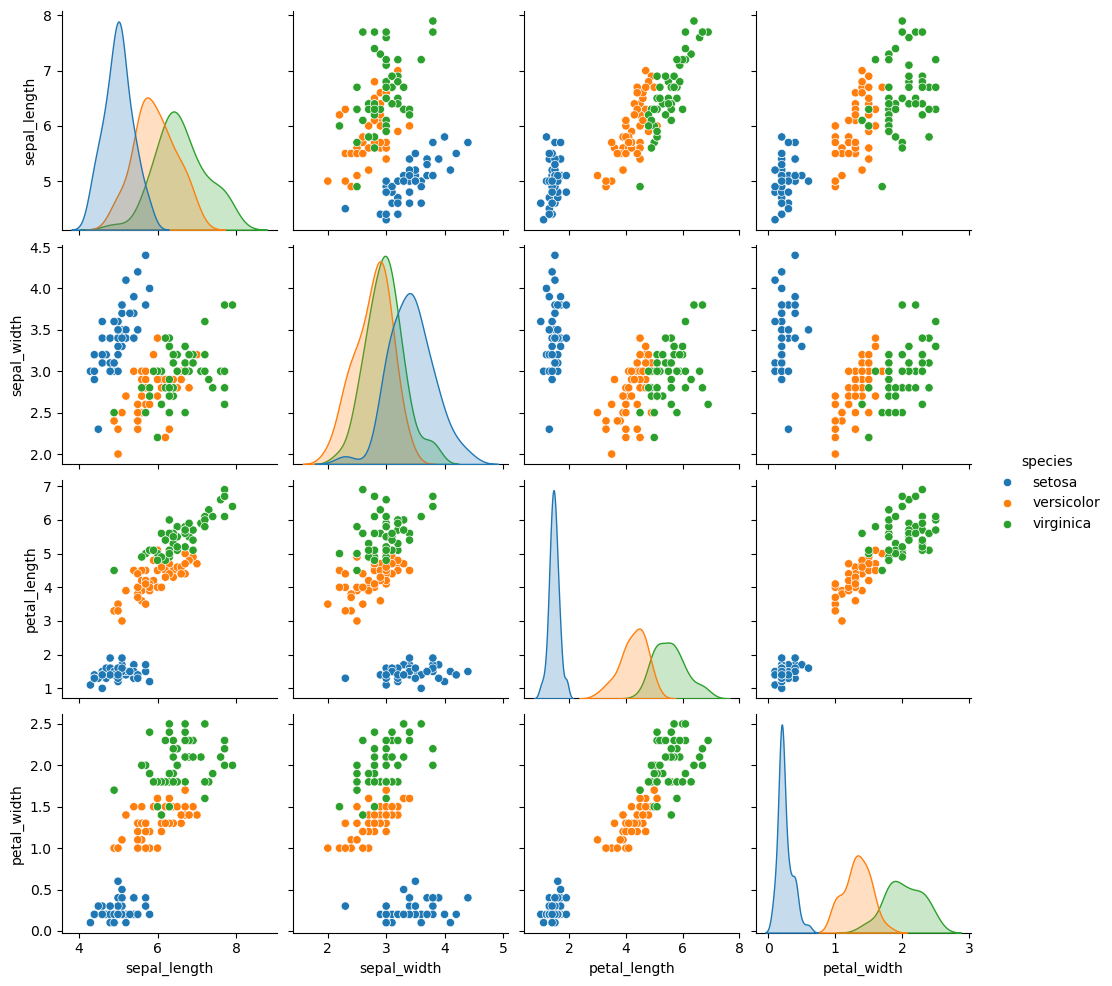

In [49]:
sns.pairplot(iris, hue='species', height=2.5)
plt.show()

In [50]:
tips = sns.load_dataset('tips')
print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


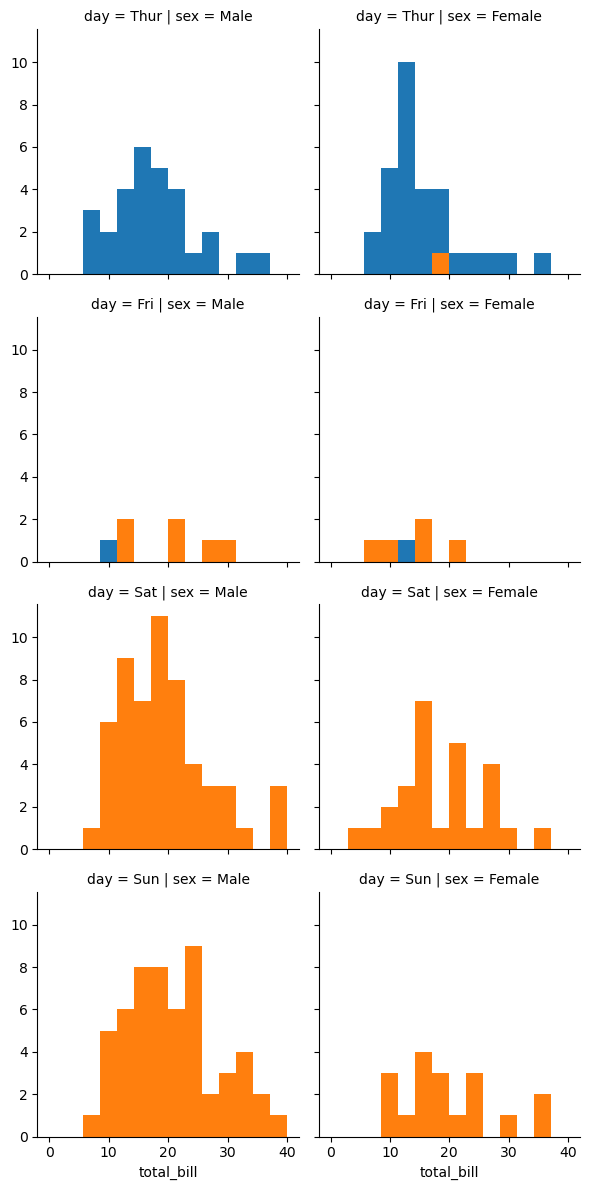

In [51]:
# гистограмы
grid = sns.FacetGrid(tips, col='sex', row='day', hue='time')
grid.map(plt.hist, 'total_bill', bins=np.linspace(0, 40, 15))
plt.show()

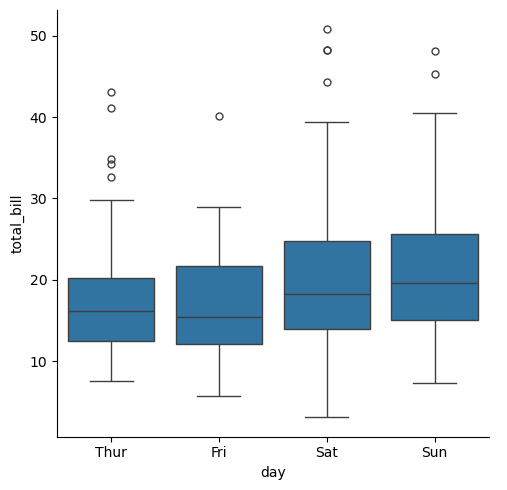

In [53]:
sns.catplot(data=tips, x='day', y='total_bill', kind='box')
plt.show()

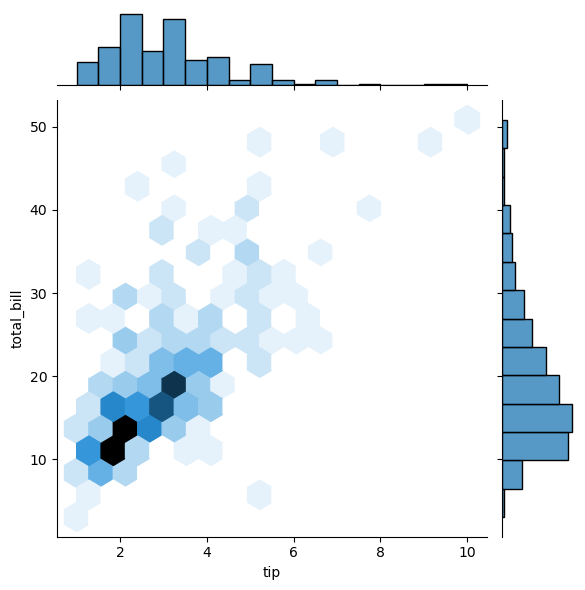

In [56]:
sns.jointplot(data=tips, x='tip', y='total_bill', kind='hex')
plt.show()

In [58]:
planets = sns.load_dataset('planets')
print (planets.head())

            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009


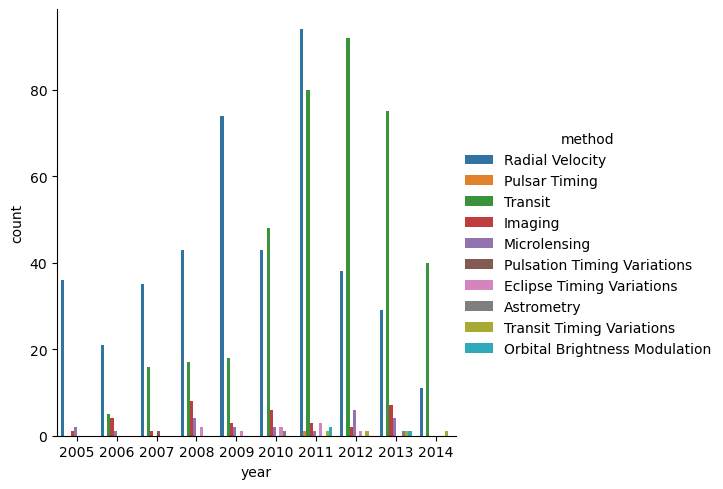

In [59]:
sns.catplot(data=planets, x='year', kind='count', hue='method', order=range(2005, 2015))
plt.show()

In [62]:
tips = sns.load_dataset('tips')
print (tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


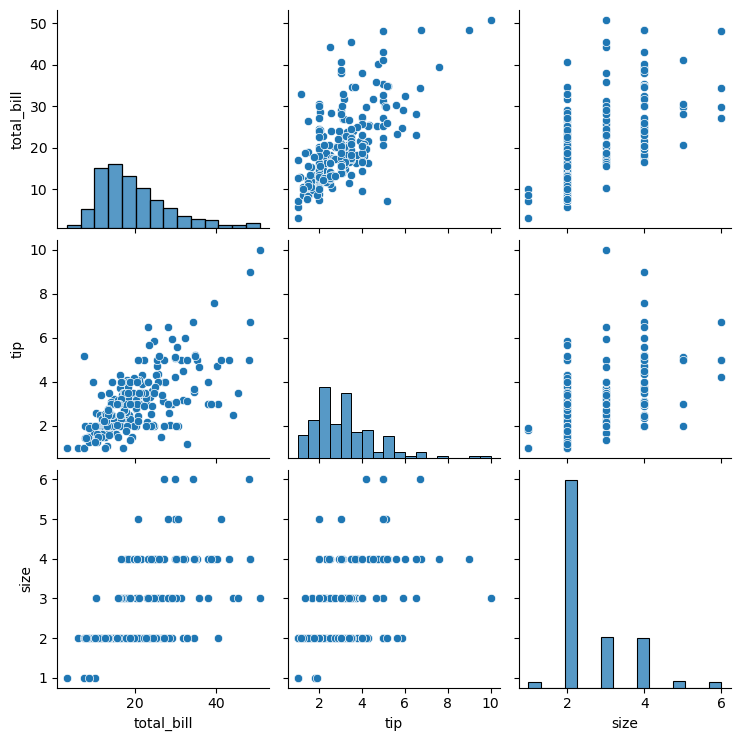

In [67]:
# Сравнение числовых данных
## Числовые пары
sns.pairplot(tips)
plt.show()

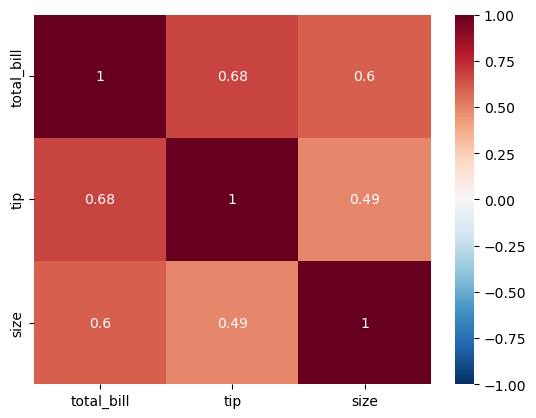

In [71]:
## Тепловая карта
tips_corr = tips[['total_bill', 'tip', 'size']]
sns.heatmap(tips_corr.corr(), cmap='RdBu_r', annot=True, vmin=-1, vmax=1)
plt.show()
# 0 - независимы
# 1 - положительная
# -1 - отрицательная

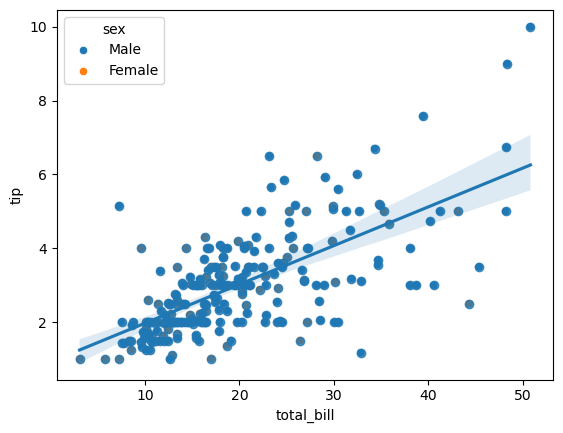

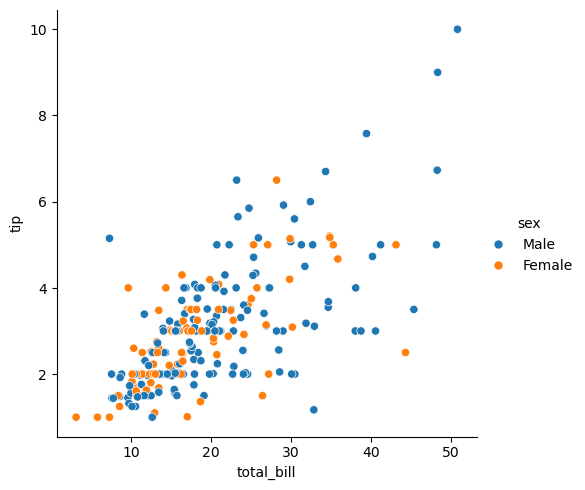

In [76]:
## Диаграмма рассеяния
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex')
sns.regplot(data=tips, x='total_bill', y='tip')
sns.relplot(data=tips, x='total_bill', y='tip', hue='sex')
plt.show()

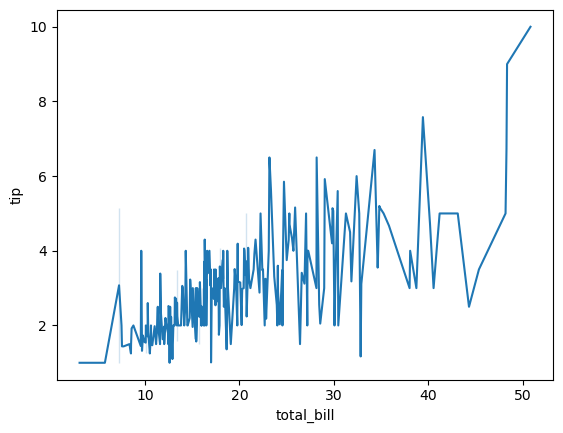

In [79]:
## Линейный график
sns.lineplot(data=tips, x='total_bill', y='tip')
plt.show()

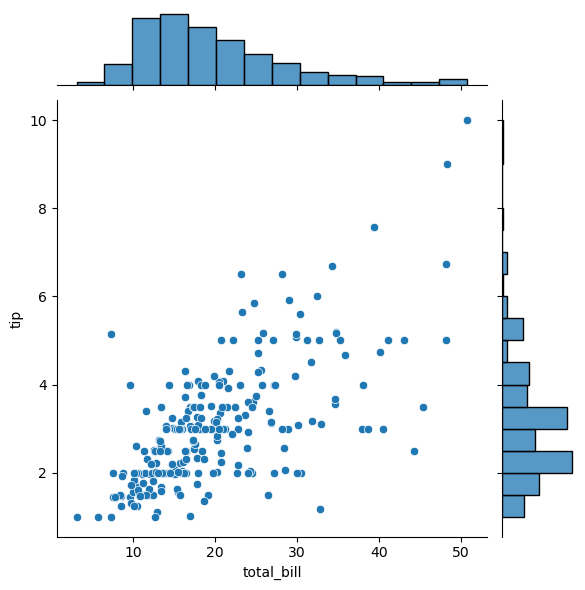

In [80]:
## Сводная диаграмма
sns.jointplot(data=tips, x='total_bill', y='tip')
plt.show()

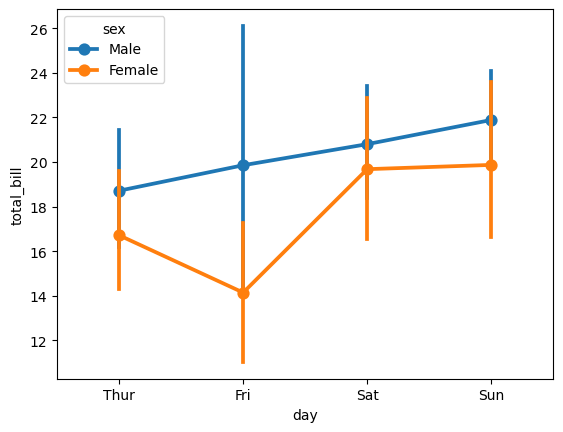

In [82]:
# Сравнение числовых и категориальных данных
# Гистограмма
#sns.barplot(data=tips, y='total_bill', x='day', hue='sex')
sns.pointplot(data=tips, y='total_bill', x='day', hue='sex')
plt.show()

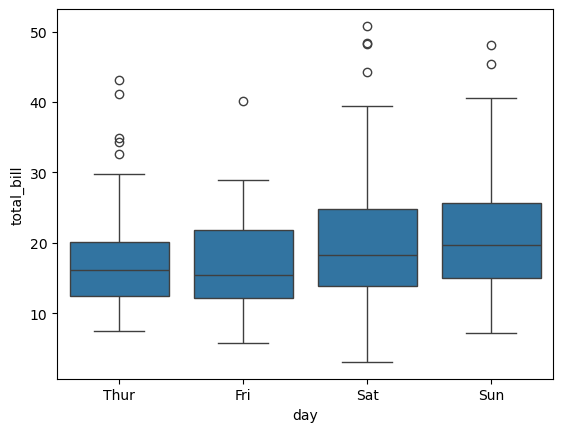

In [83]:
# Ящик "с усами"
sns.boxplot(data=tips, y='total_bill', x='day')
plt.show()

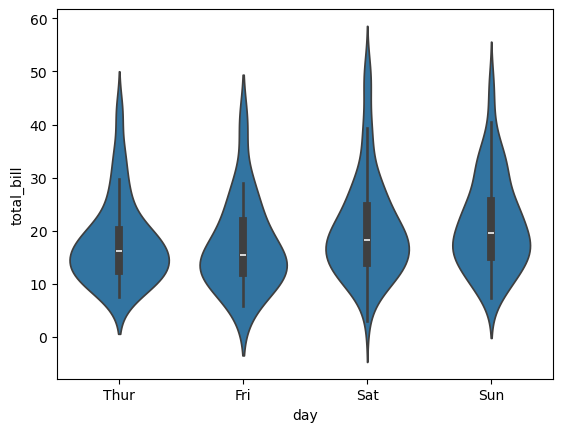

In [84]:
# Скрипичная диаграма
sns.violinplot(data=tips, y='total_bill', x='day')
plt.show()

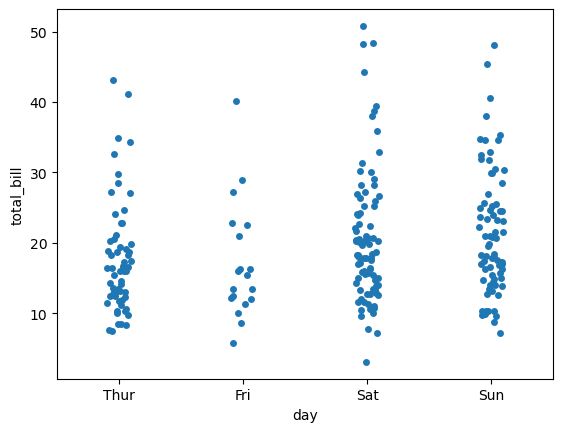

In [85]:
# Одномерная д.рассеивания
sns.stripplot(data=tips, y='total_bill', x='day')
plt.show()